<a href="https://colab.research.google.com/github/S8H1L9581/ML-LAB-CH.SC.U4CSE24039/blob/main/Linear_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install pandas numpy matplotlib scikit-learn

100%|██████████| 16.6k/16.6k [00:00<00:00, 21.1MB/s]

Extracting files...


Dataset Path: /root/.cache/kagglehub/datasets/mohithsairamreddy/salary-data/versions/4

FIRST 5 RECORDS
    Age  Gender Education Level          Job Title  Years of Experience  \
0  32.0    Male      Bachelor's  Software Engineer                  5.0   
1  28.0  Female        Master's       Data Analyst                  3.0   
2  45.0    Male             PhD     Senior Manager                 15.0   
3  36.0  Female      Bachelor's    Sales Associate                  7.0   
4  52.0    Male        Master's           Director                 20.0   

     Salary  
0   90000.0  
1   65000.0  
2  150000.0  
3   60000.0  
4  200000.0  

INTERCEPT:
58196.21064922571

COEFFICIENT:
7072.861686708188

LINEAR REGRESSION EQUATION
Salary = 7072.86 × Experience + 58196.21

R² SCORE:
0.6555973709206209

PREDICTED VS ACTUAL
      Actual Salary  Predicted Salary
1883       150000.0     121851.965830
2630        75969.0      86487.657396
498        100000.0      65269.072336
5973        60000.0      79

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(



Predicted Salary = ₹93,560.52


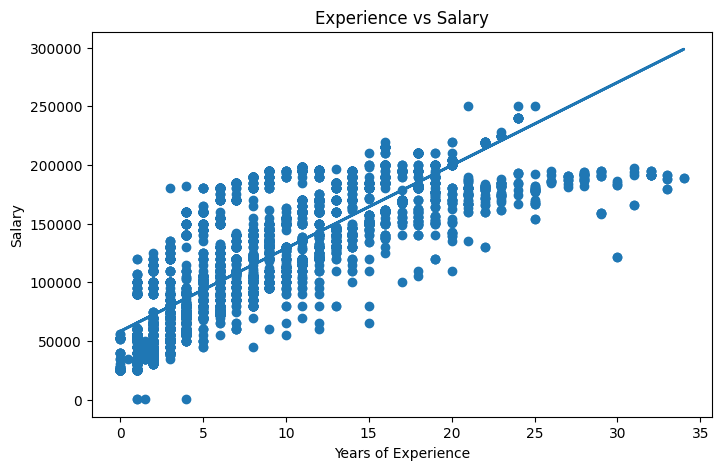

In [4]:
# ==========================================
# LINEAR REGRESSION - KAGGLE SALARY DATASET
# ==========================================

import kagglehub
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# ------------------------------------------
# DOWNLOAD DATASET
# ------------------------------------------

path = kagglehub.dataset_download(
    "mohithsairamreddy/salary-data"
)

print("Dataset Path:", path)

# ------------------------------------------
# LOAD DATASET
# ------------------------------------------

data = pd.read_csv(f"{path}/Salary_Data.csv")

# Remove missing values
data = data.dropna()

print("\nFIRST 5 RECORDS")
print(data.head())

# ------------------------------------------
# SELECT FEATURES
# ------------------------------------------

X = data[['Years of Experience']]
y = data['Salary']

# ------------------------------------------
# SPLIT DATA
# ------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# ------------------------------------------
# TRAIN MODEL
# ------------------------------------------

model = LinearRegression()
model.fit(X_train, y_train)

# ------------------------------------------
# PREDICT
# ------------------------------------------

y_pred = model.predict(X_test)

# ------------------------------------------
# MODEL DETAILS
# ------------------------------------------

print("\nINTERCEPT:")
print(model.intercept_)

print("\nCOEFFICIENT:")
print(model.coef_[0])

print("\nLINEAR REGRESSION EQUATION")
print(
    f"Salary = {model.coef_[0]:.2f} × Experience + {model.intercept_:.2f}"
)

# ------------------------------------------
# ACCURACY
# ------------------------------------------

score = r2_score(y_test, y_pred)

print("\nR² SCORE:")
print(score)

# ------------------------------------------
# ACTUAL VS PREDICTED
# ------------------------------------------

result = pd.DataFrame({
    'Actual Salary': y_test,
    'Predicted Salary': y_pred
})

print("\nPREDICTED VS ACTUAL")
print(result.head(10))

# ------------------------------------------
# USER INPUT
# ------------------------------------------

years = float(
    input("\nEnter Years of Experience: ")
)

predicted_salary = model.predict([[years]])

print(
    f"\nPredicted Salary = ₹{predicted_salary[0]:,.2f}"
)

# ------------------------------------------
# GRAPH
# ------------------------------------------

plt.figure(figsize=(8,5))

plt.scatter(
    data['Years of Experience'],
    data['Salary']
)

plt.plot(
    data['Years of Experience'],
    model.predict(X),
    linewidth=2
)

plt.title("Experience vs Salary")
plt.xlabel("Years of Experience")
plt.ylabel("Salary")

plt.show()